In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# EDA

In [2]:
data=pd.read_csv("YoutubeCommentsDataSet.csv")
data.head(5)

,Comment,Sentiment
0,lets not forget that apple pay in 2014 require...,neutral
1,here in nz 50 of retailers don’t even have con...,negative
2,i will forever acknowledge this channel with t...,positive
3,whenever i go to a place that doesn’t take app...,negative
4,apple pay is so convenient secure and easy to ...,positive


/var/folders/km/41xdld515hq8qyv7nx3qq6n80000gn/T/ipykernel_88399/343985349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment",data=data,palette="Blues")


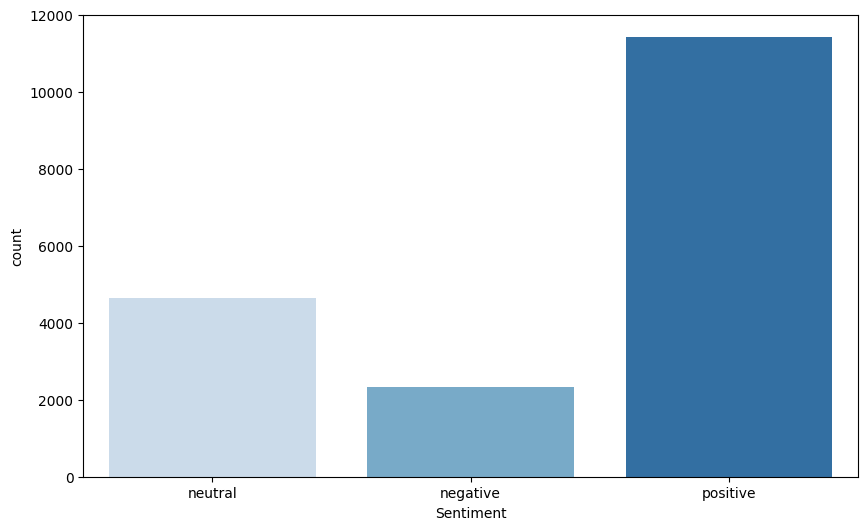

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(x="Sentiment",data=data,palette="Blues")
plt.show()

In [4]:
data["Sentiment"]=data["Sentiment"].replace({"positive":2,"negative":0,"neutral":1})

/var/folders/km/41xdld515hq8qyv7nx3qq6n80000gn/T/ipykernel_88399/2859041913.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Sentiment"]=data["Sentiment"].replace({"positive":2,"negative":0,"neutral":1})


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18408 entries, 0 to 18407
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    18364 non-null  object
 1   Sentiment  18408 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 287.8+ KB


# Handling Null Values

In [6]:
data.isnull().sum()

Comment      44
Sentiment     0
dtype: int64

In [7]:
data.dropna(inplace=True)

In [8]:
data.isnull().sum()

Comment      0
Sentiment    0
dtype: int64

# Convert into lower case

In [9]:
data["Comment"]=data["Comment"].str.lower()

# Remove Stopwords

In [10]:
def remove_stopwords_sklearn(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in ENGLISH_STOP_WORDS]
    return ' '.join(filtered_words)
data['Comment'] = data['Comment'].apply(remove_stopwords_sklearn)

# Remove Punctuation

In [11]:
def remove_punctuation(text):
    return text.translate(str.maketrans(" "," ",string.punctuation))
data["Comment"]=data["Comment"].apply(remove_punctuation)

# Feature Engineering

In [12]:
x=data["Comment"]
y=data["Sentiment"]

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
vectorizer=TfidfVectorizer(max_features=5000)
x_train=vectorizer.fit_transform(x_train)
x_test=vectorizer.transform(x_test)

# Models

In [15]:
classifier={
    "Decision Tree Classifier":DecisionTreeClassifier(),
    "Random Forest Classifier":RandomForestClassifier(),
    "SVC":SVC(),
    "Gradiant Boosting Classifier":GradientBoostingClassifier(),
    "Logistic Regression":LogisticRegression(),
    "Ada Boost Classifier":AdaBoostClassifier(),
    "LGBM Classifier":LGBMClassifier() 
}

In [16]:
results={}
for name, model in classifier.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    results[name] = {
        "Accuracy":accuracy
    }
    
    print(f"Model: {name}")
    print(f"Accuracy Score: {accuracy * 100:.2f}%")
    print("-" * 60)

Model: Decision Tree Classifier
Accuracy Score: 69.13%
------------------------------------------------------------
Model: Random Forest Classifier
Accuracy Score: 73.21%
------------------------------------------------------------
Model: SVC
Accuracy Score: 73.86%
------------------------------------------------------------
Model: Gradiant Boosting Classifier
Accuracy Score: 67.30%
------------------------------------------------------------
Model: Logistic Regression
Accuracy Score: 74.30%
------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Model: Ada Boost Classifier
Accuracy Score: 66.51%
------------------------------------------------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.183919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46060
[LightGBM] [Info] Number of data points in the train set: 14691, number of used features: 1877
[LightGBM] [Info] Start training from score -2.047489
[LightGBM] [Info] Start training from score -1.375395
[LightGBM] [Info] Start training from score -0.480941
Model: LGBM Classifier
Accuracy Score: 73.95%
------------------------------------------------------------


In [17]:
result=pd.DataFrame({
    "Classifier":["Decision Tree Classifier","Random Forest Classifier","SVC","Gradient Boosting Classifier","Logistic Regression","Ada Boost Classifier","LGBM Classifier"],
    "Accuracy":[69.13,73.21,73.86,67.27,74.30,66.51,73.95]
})

In [18]:
result

,Classifier,Accuracy
0,Decision Tree Classifier,69.41
1,Random Forest Classifier,73.07
2,SVC,73.86
3,Gradient Boosting Classifier,67.27
4,Logistic Regression,74.30
5,Ada Boost Classifier,66.51
6,LGBM Classifier,73.95


# Results

/var/folders/km/41xdld515hq8qyv7nx3qq6n80000gn/T/ipykernel_88399/191648892.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Classifier",x="Accuracy",data=result,palette="cubehelix")


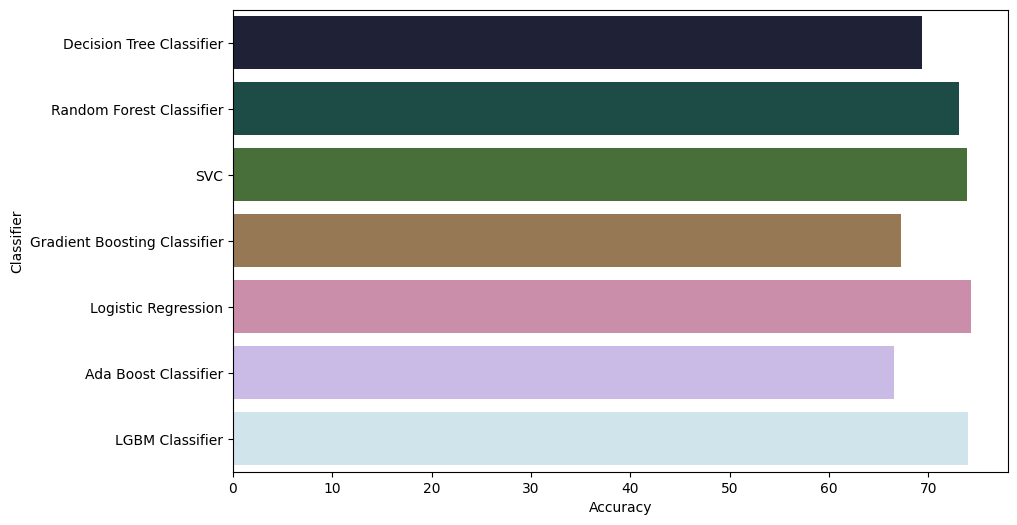

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(y="Classifier",x="Accuracy",data=result,palette="cubehelix")
plt.show()